<a href="https://colab.research.google.com/github/RISHIEDABOYINA/ADM-Lab/blob/main/Lab10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Logistic Regression Code

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

#Step 2: Load Dataset (Iris Dataset Example)

In [ ]:
df=pd.read_csv("/content/train_and_test2.csv")

#Step 3: Splitting Data into Training and Testing Sets

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Step 4: Feature Scaling

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

#Step 5: Train the Logistic Regression Model


In [ ]:
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

#Step 6: Making Predictions

In [ ]:
y_pred = model.predict(X_test) # Predict on test data


#Step 7: Evaluating the Model

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred)

#Step 8: Print Results

In [ ]:
print(f"Accuracy: {accuracy:.2f}")
print("Confusion Matrix:\n", conf_matrix)
print("Classification Report:\n", report)

Accuracy: 1.00
Confusion Matrix:
 [[10  0]
 [ 0 20]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00        20

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



#Step 9: Visualizing the Decision Boundary


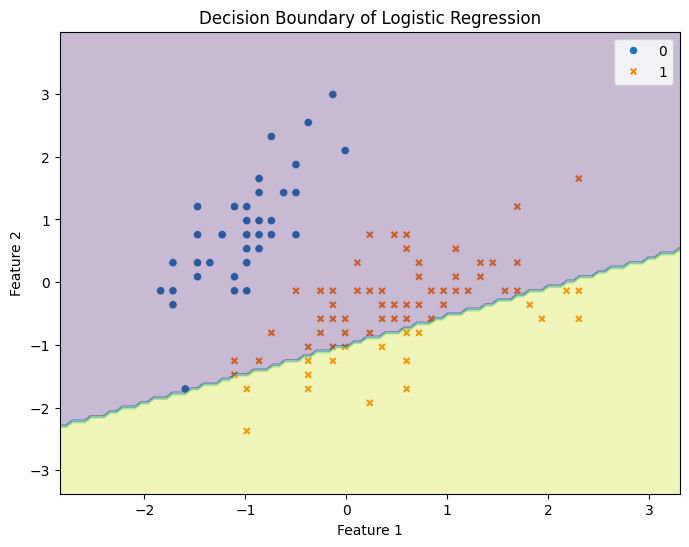

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_train[:, 0], y=X_train[:, 1], hue=y_train, style=y_train)  # Plot training data
x_min, x_max = X_train[:, 0].min() - 1, X_train[:, 0].max() + 1
y_min, y_max = X_train[:, 1].min() - 1, X_train[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))

grid_data = np.c_[xx.ravel(), yy.ravel(),
                  np.zeros_like(xx.ravel()),  # Add placeholder for feature 3
                  np.zeros_like(xx.ravel())] # Add placeholder for feature 4

grid_data_scaled = scaler.transform(grid_data)

Z = model.predict(grid_data_scaled).reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3)  # Draw decision boundary
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Decision Boundary of Logistic Regression')
plt.show()